In [1]:
%pip install matplotlib ipympl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

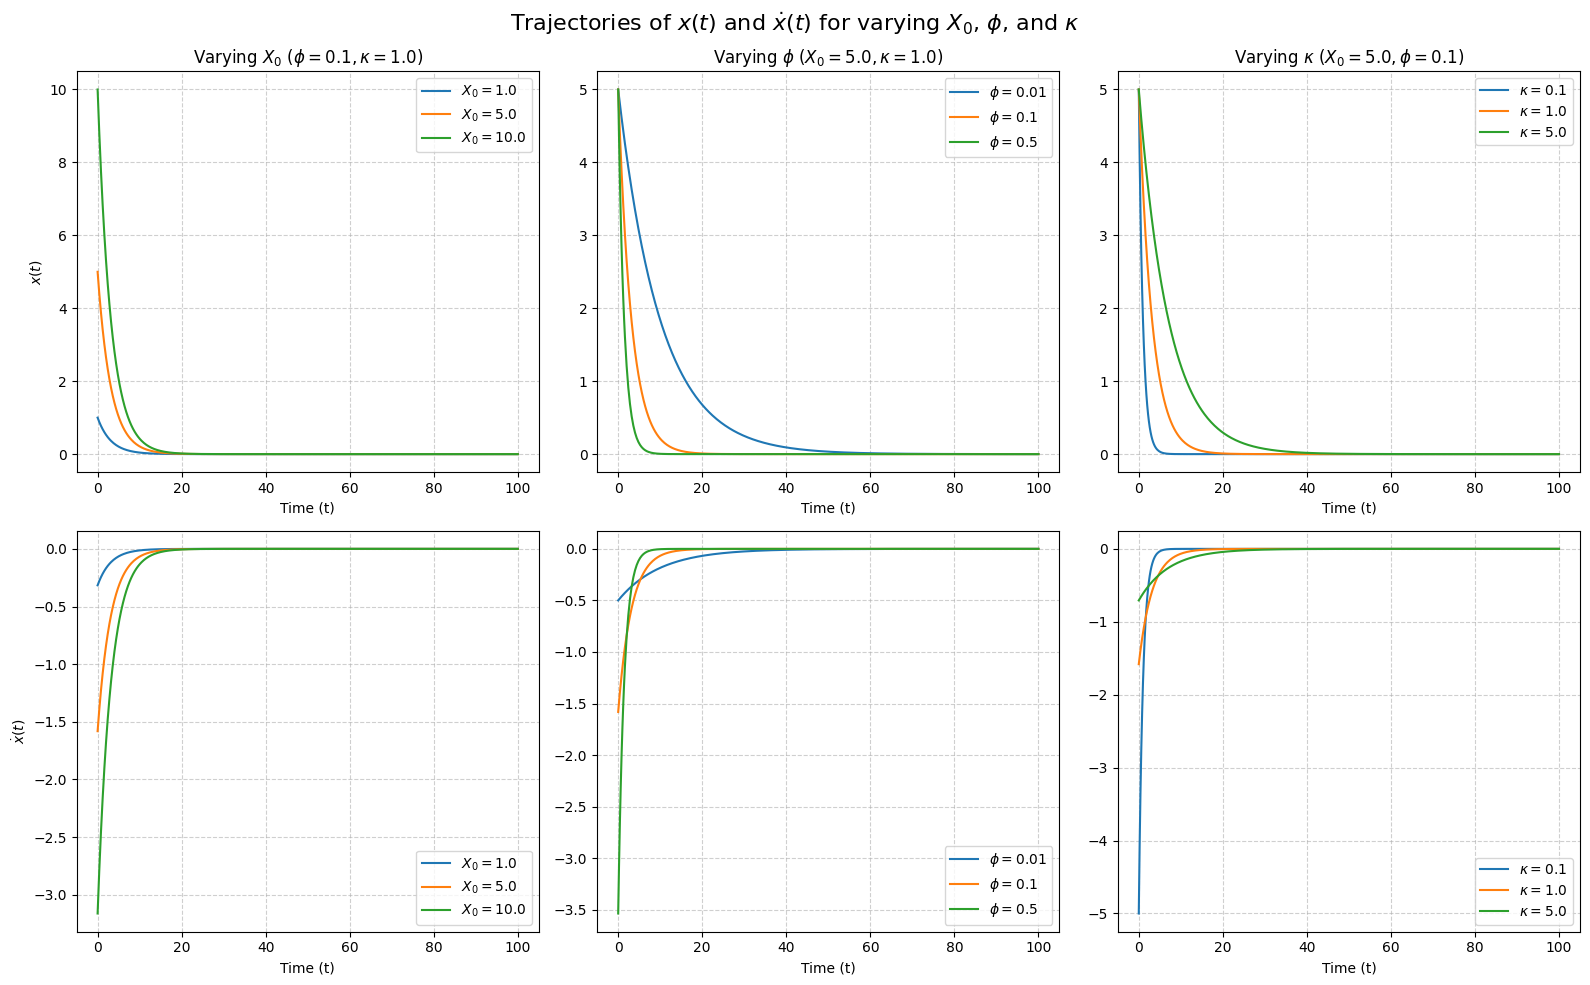

In [3]:
def calculate_omega(phi, kappa):
    return np.sqrt(phi / kappa)

def x_t(t, X0, phi, kappa, T=100):
    """Numerically stable calculation for x(t)."""
    omega = calculate_omega(phi, kappa)
    # Using the exponential equivalent of the sinh ratio to prevent overflow
    numerator = np.exp(-omega * t) - np.exp(-omega * (2*T - t))
    denominator = 1 - np.exp(-2 * omega * T)
    return X0 * (numerator / denominator)

def x_dot_t(t, X0, phi, kappa, T=100):
    """Numerically stable calculation for x_dot(t)."""
    omega = calculate_omega(phi, kappa)
    numerator = np.exp(-omega * t) + np.exp(-omega * (2*T - t))
    denominator = 1 - np.exp(-2 * omega * T)
    return -omega * X0 * (numerator / denominator)

# Base parameters
T = 100
t_array = np.linspace(0, T, 500)

# Parameter ranges to test
X0_range = [1.0, 5.0, 10.0]
phi_range = [0.01, 0.1, 0.5]
kappa_range = [0.1, 1.0, 5.0]

# Setup the plot figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(r'Trajectories of $x(t)$ and $\dot{x}(t)$ for varying $X_0$, $\phi$, and $\kappa$', fontsize=16)

# Column 1: Varying X_0 (fixed phi=0.1, kappa=1.0)
for X0 in X0_range:
    axes[0, 0].plot(t_array, x_t(t_array, X0, 0.1, 1.0), label=rf'$X_0={X0}$')
    axes[1, 0].plot(t_array, x_dot_t(t_array, X0, 0.1, 1.0), label=rf'$X_0={X0}$')
axes[0, 0].set_title(r'Varying $X_0$ ($\phi=0.1, \kappa=1.0$)')
axes[0, 0].set_ylabel(r'$x(t)$')
axes[1, 0].set_ylabel(r'$\dot{x}(t)$')

# Column 2: Varying phi (fixed X_0=5.0, kappa=1.0)
for phi in phi_range:
    axes[0, 1].plot(t_array, x_t(t_array, 5.0, phi, 1.0), label=rf'$\phi={phi}$')
    axes[1, 1].plot(t_array, x_dot_t(t_array, 5.0, phi, 1.0), label=rf'$\phi={phi}$')
axes[0, 1].set_title(r'Varying $\phi$ ($X_0=5.0, \kappa=1.0$)')

# Column 3: Varying kappa (fixed X_0=5.0, phi=0.1)
for kappa in kappa_range:
    axes[0, 2].plot(t_array, x_t(t_array, 5.0, 0.1, kappa), label=rf'$\kappa={kappa}$')
    axes[1, 2].plot(t_array, x_dot_t(t_array, 5.0, 0.1, kappa), label=rf'$\kappa={kappa}$')
axes[0, 2].set_title(r'Varying $\kappa$ ($X_0=5.0, \phi=0.1$)')

# Format all subplots
for i in range(2):
    for j in range(3):
        axes[i, j].set_xlabel('Time (t)')
        axes[i, j].grid(True, linestyle='--', alpha=0.6)
        axes[i, j].legend()

plt.tight_layout()
plt.show()

Matplotlib backend in use: widget


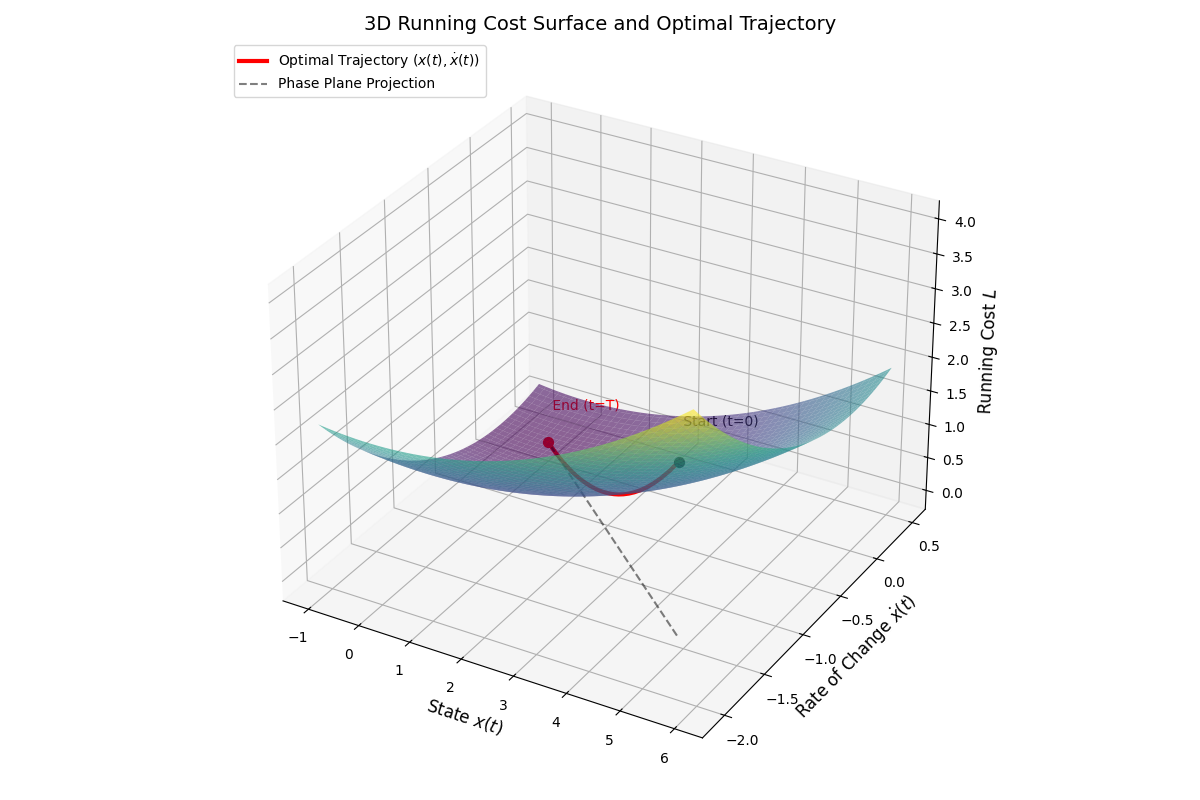

In [4]:
from IPython import get_ipython

# Try interactive backends in order. Falls back safely if unavailable.
ip = get_ipython()
backend_in_use = None
for candidate in ("widget", "notebook", "inline"):
    try:
        ip.run_line_magic("matplotlib", candidate)
        backend_in_use = candidate
        break
    except Exception:
        pass

print(f"Matplotlib backend in use: {backend_in_use}")

# Parameters
X0 = 5.0
phi = 0.1
kappa = 1.0
T = 100
omega = np.sqrt(phi / kappa)

# 1. Trajectory Functions (Numerically Stable)
def x_t(t):
    numerator = np.exp(-omega * t) - np.exp(-omega * (2*T - t))
    denominator = 1 - np.exp(-2 * omega * T)
    return X0 * (numerator / denominator)

def x_dot_t(t):
    numerator = np.exp(-omega * t) + np.exp(-omega * (2*T - t))
    denominator = 1 - np.exp(-2 * omega * T)
    return -omega * X0 * (numerator / denominator)

# 2. Running Cost Function (The Integrand)
def running_cost(x, x_dot):
    return (kappa / 2) * (x_dot ** 2) + (phi / 2) * (x ** 2)

# 3. Generate Data for the 3D Surface (The "Bowl")
x_vals = np.linspace(-1, X0 + 1, 100)
x_dot_vals = np.linspace(x_dot_t(0) - 0.5, 0.5, 100)
X, X_dot = np.meshgrid(x_vals, x_dot_vals)
Z_cost = running_cost(X, X_dot)

# 4. Generate Data for the Trajectory
t_array = np.linspace(0, T, 500)
x_traj = x_t(t_array)
x_dot_traj = x_dot_t(t_array)
z_traj = running_cost(x_traj, x_dot_traj)

# 5. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D penalty bowl (translucent)
ax.plot_surface(
    X, X_dot, Z_cost, cmap='viridis', alpha=0.6, edgecolor='none'
 )

# Plot the optimal trajectory on the bowl
ax.plot(
    x_traj, x_dot_traj, z_traj, color='red', linewidth=3,
    label=r'Optimal Trajectory $(x(t), \dot{x}(t))$'
 )

# Plot the 2D shadow of the trajectory on the "floor" (z=0)
ax.plot(
    x_traj, x_dot_traj, np.zeros_like(z_traj), color='black',
    linestyle='--', alpha=0.5, label='Phase Plane Projection'
 )

# Labels and formatting
ax.set_title('3D Running Cost Surface and Optimal Trajectory', fontsize=14)
ax.set_xlabel(r'State $x(t)$', fontsize=12)
ax.set_ylabel(r'Rate of Change $\dot{x}(t)$', fontsize=12)
ax.set_zlabel(r'Running Cost $L$', fontsize=12)

# Set starting point marker
ax.scatter(x_traj[0], x_dot_traj[0], z_traj[0], color='black', s=50, zorder=5)
ax.text(x_traj[0], x_dot_traj[0], z_traj[0] + 0.5, ' Start (t=0)', color='black')

# Set ending point marker
ax.scatter(x_traj[-1], x_dot_traj[-1], z_traj[-1], color='red', s=50, zorder=5)
ax.text(x_traj[-1], x_dot_traj[-1], z_traj[-1] + 0.5, ' End (t=T)', color='red')

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()